<p>which python<p>
<p>source .venv/bin/activate<p>
<p>jupyter notebook --no-browser --ip=0.0.0.0<p>

In [3]:
!nvidia-smi

Sat Aug  2 23:51:41 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.77.01              Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8             10W /   95W |     128MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# STEP 1: Import Required Libraries

In [41]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils import resample
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
torch.manual_seed(0)

Using device: cuda
PyTorch version: 2.7.1+cu126


# STEP 2: Load and Explore the Dataset

In [6]:
path = "./competition/"
print("Path to dataset files:", path)

DATA_DIR = os.path.join(path, "image")
TRAIN_CSV = os.path.join(path, "train.csv")
SAMPLE_SUBMISSION = os.path.join(path, "sample_submission.csv")

LABELS = ['Ink scenery', 'comic', 'cyberpunk', 'futuristic UI', 'lowpoly', 'oil painting',
          'pixel', 'realistic', 'steampunk', 'water color']
LABEL2IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX2LABEL = {idx: label for label, idx in LABEL2IDX.items()}

Path to dataset files: ./competition/


# STEP 4: Custom Dataset Class

In [7]:
class ArtDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, is_test=False):
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        self.has_labels = 'style' in self.data.columns and not is_test

        # Filter only known styles
        if self.has_labels:
            original_len = len(self.data)
            self.data = self.data[self.data['style'].isin(LABEL2IDX.keys())].reset_index(drop=True)
            filtered_len = len(self.data)
            print(f"Filtered out {original_len - filtered_len} unknown-labeled samples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        uuid = self.data.iloc[idx]['uuid']
        img_path = os.path.join(self.img_dir, f"{uuid}.png")

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            style = self.data.iloc[idx]['style']
            label = LABEL2IDX[style]
            return image, label
        else:
            return image, uuid


# STEP 5: Data Transforms and Augmentation

In [8]:
def pad_to_square(img, fill=0):
    w, h = img.size
    max_wh = max(w, h)
    pad_w = (max_wh - w) // 2
    pad_h = (max_wh - h) // 2
    padding = (pad_w, pad_h, max_wh - w - pad_w, max_wh - h - pad_h)
    return transforms.functional.pad(img, padding, fill=fill)

In [9]:
train_transforms = transforms.Compose([
	transforms.Lambda(pad_to_square),
    transforms.Resize((224, 224)),
	transforms.RandomHorizontalFlip(p=0.5),
	transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
	transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define transforms for validation/test (no augmentation)
val_transforms = transforms.Compose([
	transforms.Lambda(pad_to_square),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Data transforms defined:")
print("- Training: Pad, Resize, Rotation, Flip, ColorJitter, Normalize")
print("- Validation: Pad, Resize, Normalize only")

Data transforms defined:
- Training: Pad, Resize, Rotation, Flip, ColorJitter, Normalize
- Validation: Pad, Resize, Normalize only


# STEP 6: Create Data Loaders

In [10]:
# Load the training data and split it into train/validation
train_data = pd.read_csv(TRAIN_CSV)

# Filter only known styles
original_len = len(train_data)
train_data = train_data[train_data['style'].isin(LABEL2IDX.keys())].reset_index(drop=True)
filtered_len = len(train_data)
print(f"Filtered out {original_len - filtered_len} unknown-labeled samples from training data")

# Split the data into train and validation sets
train_df, val_df = train_test_split(
    train_data, 
    test_size=0.3,  # 30% for validation
    random_state=42, 
    stratify=train_data['style']  # Ensure balanced split across classes
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Class distribution in training set:")
print(train_df['style'].value_counts())

Filtered out 0 unknown-labeled samples from training data
Training samples: 4529
Validation samples: 1942
Class distribution in training set:
style
oil painting     766
futuristic UI    761
Ink scenery      659
water color      598
pixel            487
realistic        414
steampunk        329
lowpoly          254
cyberpunk        169
comic             92
Name: count, dtype: int64


In [11]:
def targeted_oversampling(df, style_column='style', target_classes=None, target_size=500):
    """
    Oversample only specific minority classes to a target size
    
    Args:
        df: DataFrame with image data
        style_column: Column name containing class labels
        target_classes: List of classes to oversample
        target_size: Target number of samples for each specified class
    
    Returns:
        DataFrame with oversampled minority classes
    """
    if target_classes is None:
        target_classes = ['lowpoly', 'cyberpunk', 'comic', 'steampunk']
    
    print(f"Oversampling classes: {target_classes}")
    print(f"Target size per class: {target_size}")
    print("-" * 50)
    
    # Start with original dataframe
    oversampled_dfs = []
    
    for style in df[style_column].unique():
        class_data = df[df[style_column] == style]
        current_size = len(class_data)
        
        if style in target_classes and current_size < target_size:
            # Oversample this class
            samples_needed = target_size - current_size
            
            # Random sampling with replacement
            oversampled_data = resample(
                class_data, 
                replace=True, 
                n_samples=target_size, 
                random_state=42
            )
            
            print(f"{style}: {current_size} -> {target_size} (+{samples_needed})")
            oversampled_dfs.append(oversampled_data)
            
        else:
            # Keep original data for other classes
            print(f"{style}: {current_size} (unchanged)")
            oversampled_dfs.append(class_data)
    
    # Combine all dataframes
    final_df = pd.concat(oversampled_dfs, ignore_index=True)
    
    print("-" * 50)
    print(f"Original dataset size: {len(df)}")
    print(f"Oversampled dataset size: {len(final_df)}")
    print(f"Added {len(final_df) - len(df)} samples")
    
    return final_df

In [12]:
target_class = ['realistic','lowpoly', 'cyberpunk', 'comic', 'steampunk']
train_df = targeted_oversampling(train_df, style_column='style', target_classes=target_class, target_size=500)

Oversampling classes: ['realistic', 'lowpoly', 'cyberpunk', 'comic', 'steampunk']
Target size per class: 500
--------------------------------------------------
pixel: 487 (unchanged)
futuristic UI: 761 (unchanged)
steampunk: 329 -> 500 (+171)
realistic: 414 -> 500 (+86)
Ink scenery: 659 (unchanged)
oil painting: 766 (unchanged)
comic: 92 -> 500 (+408)
water color: 598 (unchanged)
lowpoly: 254 -> 500 (+246)
cyberpunk: 169 -> 500 (+331)
--------------------------------------------------
Original dataset size: 4529
Oversampled dataset size: 5771
Added 1242 samples


In [13]:
# Save the split data to temporary CSV files
train_df.to_csv('temp_train.csv', index=False)
val_df.to_csv('temp_val.csv', index=False)

# Create datasets
train_dataset = ArtDataset('temp_train.csv', DATA_DIR, train_transforms)
val_dataset = ArtDataset('temp_val.csv', DATA_DIR, val_transforms)
test_dataset = ArtDataset(SAMPLE_SUBMISSION, DATA_DIR, val_transforms, is_test=True)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Filtered out 0 unknown-labeled samples
Filtered out 0 unknown-labeled samples
Train loader batches: 181
Validation loader batches: 61
Test loader batches: 45


# STEP 7: Visualize Sample Data

In [14]:
def imshow(tensor, title=None):
    """Display a tensor as an image"""
    # Denormalize the image
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    image = tensor.clone().detach()
    image = image.numpy().transpose((1, 2, 0))
    image = std * image + mean
    image = np.clip(image, 0, 1)
    
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')

def visualize_batch(data_loader, num_samples=8):
    """Visualize a batch of images"""
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    
    plt.figure(figsize=(12, 6))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i + 1)
        imshow(images[i], title=f'Class {labels[i].item()}')
    plt.tight_layout()
    plt.show()


In [15]:
def visualize_batch_sample(data_loader, num_samples=8):
    """Visualize a batch of images"""
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    
    plt.figure(figsize=(12, 6))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i + 1)
        imshow(images[i], '')
    plt.tight_layout()
    plt.show()


In [ ]:
# Visualize training samples
print("Sample training images:")
visualize_batch(train_loader)

In [ ]:
# Visualize sample samples
print("Sample training images:")
visualize_batch_sample(train_loader)

# STEP 8: Model Architecture

In [16]:
class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(EfficientNetClassifier, self).__init__()
        
        self.backbone = models.efficientnet_b0(pretrained=pretrained)
        num_features = self.backbone.classifier[1].in_features
        
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

num_classes = len(LABEL2IDX)

# Create model
model = EfficientNetClassifier(num_classes, pretrained=True)

# Move model to device
model = model.to(device)

# Display model architecture
print(f"Model created with {num_classes} classes")
print(f"Model moved to {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model created with 10 classes
Model moved to cuda
Total parameters: 4,338,054
Trainable parameters: 4,338,054


# STEP 9: Loss Function and Optimizer

In [17]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

print("Training setup:")
print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"Scheduler: StepLR (step_size=10, gamma=0.1)")

Training setup:
Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001, weight_decay=1e-4)
Scheduler: StepLR (step_size=10, gamma=0.1)


# STEP 10: Training Functions

In [18]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train the model for one epoch
    
    Returns:
        Average loss and accuracy for the epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc='Training')
    
    for batch_idx, (images, labels) in enumerate(progress_bar):
        images, labels = images.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

In [19]:
def validate_epoch(model, val_loader, criterion, device):
    """
    Validate the model for one epoch
    
    Returns:
        Average loss, accuracy, and F1 score for the epoch
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc='Validation')
        
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Store predictions for F1 score calculation
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    
    # Calculate F1 score
    f1_macro = f1_score(all_labels, all_predictions, average='macro')
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
    
    return epoch_loss, epoch_acc, f1_macro, f1_weighted

### Load model

In [20]:
# Updated load_model function to return history
def load_model_with_history(model_path, num_classes):
    """
    Load a saved model along with its training history
    """
    model = EfficientNetClassifier(num_classes)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    
    # Extract history if available
    history = checkpoint.get('history', None)
    f1_score = checkpoint.get('f1_score', 0.0)
    
    print(f"Model loaded from {model_path}")
    print(f"Best F1 score: {f1_score:.4f}")
    
    return model, history

# STEP 11: Training Loop

In [21]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    """
    Complete training loop with validation
    
    Returns:
        Training history dictionary
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1_macro': [],
        'val_f1_weighted': []
    }
    
    best_f1 = 0.0
    best_model_state = None
    # best_model_state = load_model_with_history('weigth_zclass_ท่อตรง.pth', num_classes)
    
    print(f"Starting training for {num_epochs} epochs...")
    print("-" * 50)
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation
        val_loss, val_acc, val_f1_macro, val_f1_weighted = validate_epoch(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step()
        
        # Save best model
        if val_f1_weighted > best_f1:
            best_f1 = val_f1_weighted
            best_model_state = model.state_dict().copy()
            print(f"New best F1 score: {best_f1:.4f} F1_weighted, saving model state")
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1_macro'].append(val_f1_macro)
        history['val_f1_weighted'].append(val_f1_weighted)
        
        # Print epoch results
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        print(f'Val F1 (Macro): {val_f1_macro:.4f}, Val F1 (Weighted): {val_f1_weighted:.4f}')
        print(f'Current LR: {optimizer.param_groups[0]["lr"]:.6f}')
        print("-" * 50)
        
        # Early stopping check
        if epoch > 10 and val_f1_macro < max(history['val_f1_weighted'][-10:]) - 0.01:
            print("Early stopping triggered!")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Best model loaded with F1 score: {best_f1:.4f}")
    
    return history

In [ ]:
# Start training
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20)

# STEP 12: Training Visualization

In [22]:
def plot_training_history(history):
    """
    Plot training history
    """
    plt.figure(figsize=(15, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Accuracy plot
    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Training Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    # F1 Score plot
    plt.subplot(1, 3, 3)
    plt.plot(history['val_f1_macro'], label='F1 Macro')
    plt.plot(history['val_f1_weighted'], label='F1 Weighted')
    plt.title('F1 Scores')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot training history
plot_training_history(history)

# STEP 13: Model Evaluation

In [23]:
def evaluate_model(model, val_loader, device):
    """
    Comprehensive model evaluation
    """
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    # Calculate metrics
    f1_macro = f1_score(all_labels, all_predictions, average='macro')
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
    
    print(f"Final F1 Score (Macro): {f1_macro:.4f}")
    print(f"Final F1 Score (Weighted): {f1_weighted:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return f1_macro, f1_weighted, all_probabilities

In [ ]:
# Evaluate the model
f1_macro, f1_weighted, val_probabilities = evaluate_model(model, val_loader, device)

# STEP 14: Test Data Prediction

In [26]:
def zclassifier_predict(model, data_loader, device):
    """
    Zclassifier prediction method - uses max logit values for confidence scoring
    """
    model.eval()
    all_predictions = []
    all_confidence_scores = []
    all_outputs = []
    
    with torch.no_grad():
        for batch_data in tqdm(data_loader, desc='Zclassifier Prediction'):
            images = batch_data[0].to(device)
            
            # Forward pass - get raw logits
            logits = model(images)
            
            # Get softmax probabilities for predictions
            probabilities = F.softmax(logits, dim=1)
            
            # Get predictions from probabilities
            _, predicted = torch.max(probabilities, 1)
            
            # Use max logit values as confidence scores (Zclassifier approach)
            max_logits, _ = torch.max(logits, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_confidence_scores.extend(max_logits.cpu().numpy())
            all_outputs.extend(probabilities.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_confidence_scores), np.array(all_outputs)

In [25]:
print("Making predictions on test data using Zclassifier...")
test_predictions, test_logit_scores, test_outputs = zclassifier_predict(model, test_loader, device)

Making predictions on test data using Zclassifier...


TypeError: zclassifier_predict() got an unexpected keyword argument 'temperature'

# STEP 15: Handle Unknown Class (11th Class)

In [29]:
def detect_unknown_class_zclassifier(predictions, logit_scores, threshold=2.0):
    """
    Detect potential unknown class based on max logit values (Zclassifier approach).
    
    Args: 
        predictions: Predicted class labels
        logit_scores: Maximum logit values for each prediction
        threshold: Logit threshold below which we classify as unknown
    
    Returns:
        Modified predictions with unknown class label (e.g., class 11)
    """
    modified_predictions = predictions.copy()
    
    unknown_mask = logit_scores < threshold
    modified_predictions[unknown_mask] = 11  # unknown class
    
    print(f"Detected {np.sum(unknown_mask)} potential unknown class samples")
    print(f"Percentage of unknown samples: {np.sum(unknown_mask)/len(predictions)*100:.2f}%")
    print(f"Logit score statistics:")
    print(f"  Min: {np.min(logit_scores):.3f}")
    print(f"  Max: {np.max(logit_scores):.3f}")
    print(f"  Mean: {np.mean(logit_scores):.3f}")
    print(f"  Std: {np.std(logit_scores):.3f}")
    
    return modified_predictions

In [ ]:
final_predictions = detect_unknown_class_zclassifier(test_predictions, test_confidence_scores, threshold=6.5)

# STEP 16: Create Submission File

In [30]:
def create_submission(test_dataset, predictions, output_file="submission_zclass.csv", unknown_label="UNK"):
    """
    Create submission file using test dataset and predictions
    
    Args:
        test_dataset: ArtDataset instance for test data
        predictions: Array of predicted class indices
        output_file: Output CSV filename
        unknown_label: Label for unknown/out-of-distribution samples
    """
    submission_data = []

    # Use the provided LABELS list for class mapping
    LABELS = ['Ink scenery', 'comic', 'cyberpunk', 'futuristic UI', 'lowpoly', 'oil painting',
              'pixel', 'realistic', 'steampunk', 'water color']
    
    # Create idx_to_class mapping from LABELS
    idx_to_class = {i: label for i, label in enumerate(LABELS)}

    for i in range(len(test_dataset)):
        # Get UUID from dataset
        uuid = test_dataset.data.iloc[i]['uuid']
        
        pred_class_id = predictions[i]

        # If prediction is an unknown class index, name it "unknown"
        if pred_class_id in idx_to_class:
            pred_class_name = idx_to_class[pred_class_id]
        else:
            pred_class_name = unknown_label

        submission_data.append({
            "uuid": uuid,
            "style": pred_class_name
        })

    submission_df = pd.DataFrame(submission_data)
    submission_df.to_csv(output_file, index=False)
    print(f"Saved submission to {output_file}")
    print(f"Submission shape: {submission_df.shape}")
    print(f"Sample predictions:")
    print(submission_df.head())

    return submission_df

In [ ]:
# Create submission file
submission = create_submission(test_dataset, final_predictions, output_file="submission_zclass_editted_oversampling.csv")

# STEP 17: Model Saving and Loading

In [ ]:
# Save the trained model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_classes': num_classes,
    'f1_score': f1_weighted,
    'history': history
}, 'weigth_zclass_ท่อตรง_oversampling.pth')

In [31]:
# Option to load model instead of training
USE_SAVED_MODEL = True

if USE_SAVED_MODEL:
    # Load the saved model
    loaded_model, history = load_model_with_history('weigth_zclass_ท่อตรง_oversampling.pth', num_classes)
    model = loaded_model
    
    # If no history available, skip visualization or create dummy
    if history is None:
        print("No training history available - skipping training plots")
        # You can either skip plot_training_history() or create dummy data
        history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_f1_macro': [],
            'val_f1_weighted': []
        }
else:
    # Use the freshly trained model (existing code continues)
    history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=20)

Model loaded from weigth_zclass_ท่อตรง_oversampling.pth
Best F1 score: 0.9334


Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:29<00:00,  2.09it/s]


Final F1 Score (Macro): 0.9255
Final F1 Score (Weighted): 0.9334

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       283
           1       0.91      0.80      0.85        40
           2       0.99      0.94      0.96        72
           3       0.94      0.96      0.95       326
           4       0.91      0.85      0.88       109
           5       0.96      0.98      0.97       328
           6       0.94      0.92      0.93       209
           7       0.93      0.91      0.92       177
           8       0.98      0.94      0.96       141
           9       0.92      0.93      0.92       257

    accuracy                           0.93      1942
   macro avg       0.94      0.92      0.93      1942
weighted avg       0.93      0.93      0.93      1942



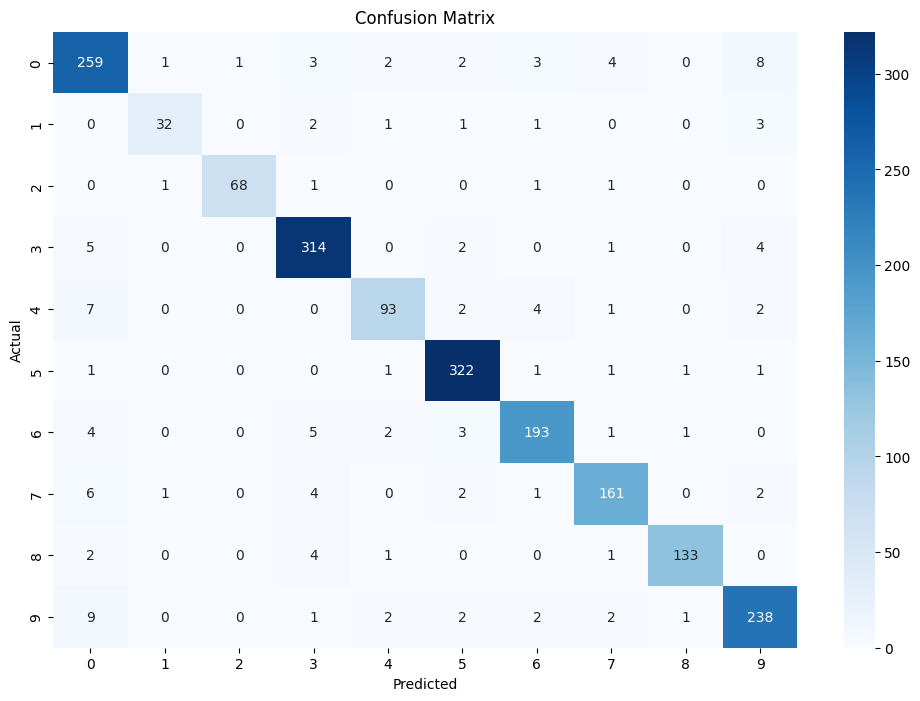

In [32]:
if USE_SAVED_MODEL:
	# Continue with evaluation
	f1_macro, f1_weighted, val_probabilities = evaluate_model(model, val_loader, device)

In [33]:
if USE_SAVED_MODEL:
    # Make predictions on test data using Zclassifier
    print("Making predictions on test data using Zclassifier...")
    test_predictions, test_logit_scores, test_outputs = zclassifier_predict(model, test_loader, device)

Making predictions on test data using Zclassifier...


Zclassifier Prediction: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 45/45 [00:19<00:00,  2.32it/s]


In [36]:
if USE_SAVED_MODEL:
    # Detect unknown class samples using logit scores
    final_predictions = detect_unknown_class_zclassifier(test_predictions, test_logit_scores, threshold=6.75)

Detected 338 potential unknown class samples
Percentage of unknown samples: 23.95%
Logit score statistics:
  Min: 1.515
  Max: 29.039
  Mean: 11.242
  Std: 5.116


In [37]:
if USE_SAVED_MODEL:
    # Create submission file
    submission = create_submission(test_dataset, final_predictions, output_file="submission_zclass_editted_oversampling.csv")

Saved submission to submission_zclass_editted_oversampling.csv
Submission shape: (1411, 2)
Sample predictions:
                                   uuid    style
0  ffcde60a-0158-4cc3-9b53-694bbddf5cb7      UNK
1  80804fd8-1350-4c19-bcf1-4a3d232cfa15  lowpoly
2  03bb4234-73a7-43cf-a5f5-32e0ebe89df2    pixel
3  0593a1cc-a6c9-4d52-aa2e-9cee91d2447e      UNK
4  fa66a70b-eee6-4d18-bc41-fc90968097cc      UNK
